# RUN / Train and Tune Models

### NOTES
* Set Target Mode in config.yaml
  * step: for multi-direct standard t+1, t+2, …, t+H log returns
  * rolling: for cumulative log return

* Set Save Variable if Figures and Data should be saved or not
* Set Experiment to run:
  * linreg
  * xgboost
  * random_forest
  * cnn
  * lstm

In [66]:
SAVE = True
MODEL = "xgboost" # linreg, xgboost, random_forest, cnn, lstm

## Imports

In [67]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.features import create_features_and_target
from src.models.factory import experiments
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.runners import run_experiments
from src.utils import results_to_df, set_seed

## Config

* Set Save to either True or False
  * This will overwrite existing data, figures and models
* Target Mode from yaml (rolling or step)

In [68]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.n_trials
SPLITS = cfg.runtime.n_splits
TRAIN_RATIO = cfg.runtime.train_ratio
VAL_RATIO = cfg.runtime.val_ratio
GAP = cfg.runtime.gap
SUBSAMPLE_TRAIN = cfg.runtime.subsample_train
N_JOBS = cfg.runtime.n_jobs
TARGET_MODE = cfg.runtime.target_mode  # adjust target mode in config.yaml (step or rolling)
rng = set_seed(SEED)

2025-09-20 08:20:28,866 - INFO - src.utils - Global random seed set to 42


## Features
* Sentiment Notebook has to run first

In [69]:
df_price_sent = pd.read_csv(Path(cfg.data.processed_dir) / "prices_with_sentiment.csv")

In [70]:
df_full = create_features_and_target(
    df=df_price_sent,
    forecast_horizon=cfg.runtime.horizon,
    back_horizon=cfg.runtime.lag_horizon,
    training=True,
    target_mode=cfg.runtime.target_mode,  # step or rolling
    custom_horizons=cfg.runtime.horizon_list  # omit if step
)

## Choose Experiment to Run
* Set Experiment

In [71]:
EXP = [next(e for e in experiments if e.name == MODEL)]
EXP

[Experiment(name='xgboost', build=<function <lambda> at 0x000001EA94507920>, include_sentiment=True)]

In [72]:
results = run_experiments(
    df=df_full,
    out_dir=Path(cfg.data.processed_dir),
    experiments=EXP,
    forecast_horizon=HORIZON,
    random_state=SEED,
    n_trials=TRIALS[0] if MODEL in ["cnn", "lstm"] else TRIALS[1],
    n_splits=SPLITS,
    gap=GAP,
    subsample_train=SUBSAMPLE_TRAIN,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    n_jobs=N_JOBS,
    target_mode=TARGET_MODE,
    save=SAVE
)

2025-09-20 08:20:28,907 - INFO - src.utils - Global random seed set to 42
2025-09-20 08:20:28,922 - INFO - ModelTrainer - Initialized trainer for xgboost
2025-09-20 08:21:00,162 - INFO - ModelTrainer - Initialized trainer for xgboost
2025-09-20 08:21:00,274 - INFO - ModelTrainer - Evaluating model...


## Plots

In [73]:
train, val, test, forecast = time_series_split(df_full, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, horizon=HORIZON)

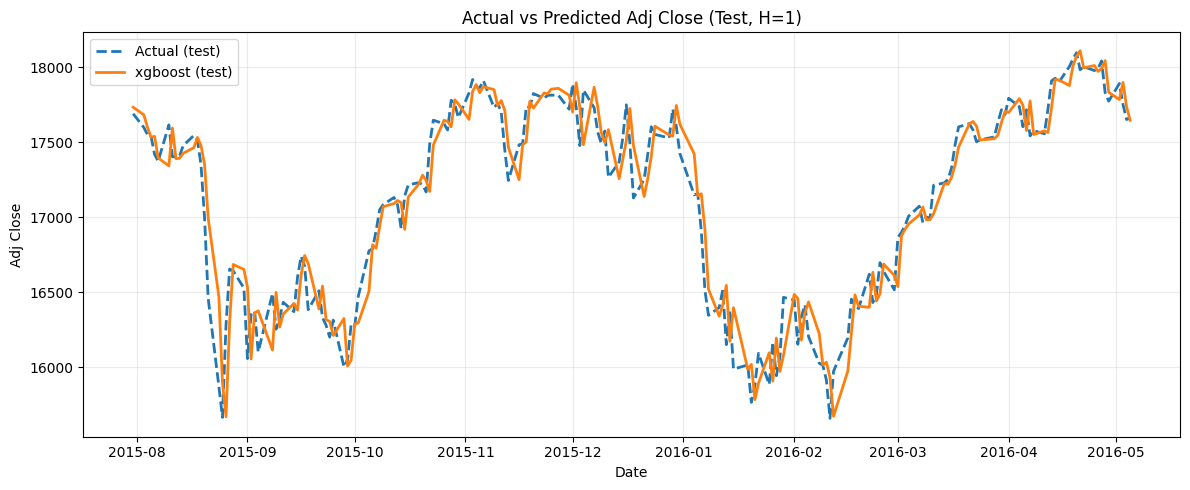

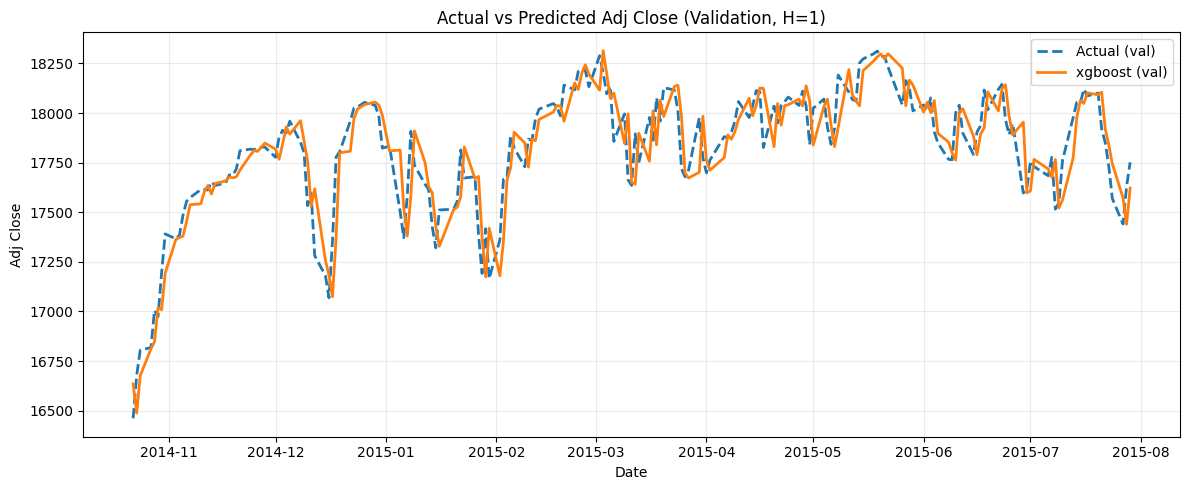

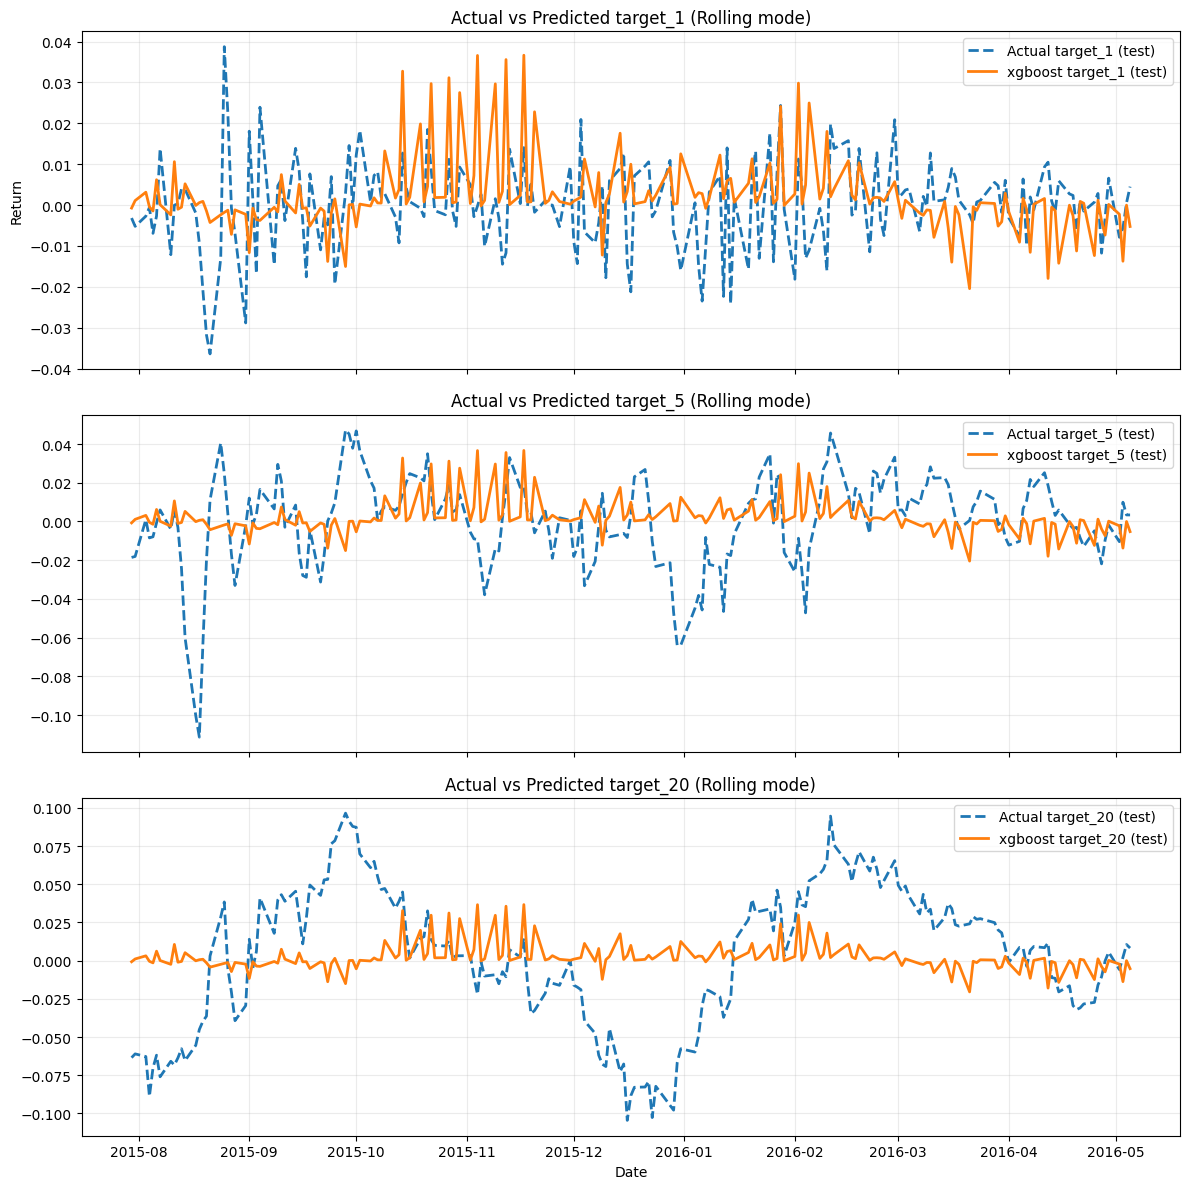

In [74]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL}_actual_vs_predicted_adj_close_test.png", save=SAVE)
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL}_actual_vs_predicted_adj_close_val.png", save=SAVE)
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL}_returns.png", phase="test", target_mode=TARGET_MODE, save=SAVE)
if TARGET_MODE == "step":
    plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL}_forecast.png", save=SAVE)
    plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL}_forecast_diagnostics.png", save=SAVE)

## Metrics

In [75]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,n_estimators,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,gamma,max_bin,grow_policy,objective,eval_metric,subsample,colsample_bytree,tree_method,max_leaves,random_state
0,xgboost,100,0.056876,3,2.342331,0.089663,1.449503,0.382626,128,depthwise,reg:absoluteerror,mae,0.824255,0.819524,hist,0,42


In [76]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,xgboost,0.020634,0.000849,0.029141,0.067351,0.576592


In [77]:
metrics_summary = results_to_df(results, ["metrics", "test", "per_horizon"])
metrics_summary = metrics_summary[metrics_summary["model"] == MODEL]
metrics_summary

,model,per_horizon,mae,mse,rmse,r2,directional_accuracy
0,xgboost,1,0.008142,0.000119,0.010914,-0.000394,0.575130
1,xgboost,2,0.017504,0.000564,0.023749,-0.000947,0.520619
2,xgboost,3,0.036257,0.001864,0.043179,0.087475,0.634021


In [78]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()